# Lab 6: Orientation Control

Goal: control the **yaw angle** of the robot using IMU gyro feedback and PID.

Experiments:
1. **P control** — baseline, tune KP (target = 90°)
2. **PD control** — add derivative to reduce overshoot, test angle wrap-around (target = -180°)
3. **Derivative kick demo** — show spike when setpoint changes, then fix with LPF
4. **PID control** — add integral to help with steady-state error
5. **Setpoint change** — change target mid-run (90° → -90°)

---
### Required Arduino changes (add to `ble_arduino.ino`)

Add to the `CommandTypes` enum:
```cpp
ORIENT_START      = 33,  // Start orientation PID
ORIENT_STOP       = 34,  // Emergency stop
GET_ORIENT_DATA   = 35,  // Stream yaw + PID records
SET_ORIENT_GAINS  = 36,  // KP|KI|KD
SET_ORIENT_TARGET = 37,  // target angle (degrees)
```

**Data format sent from Arduino:**
```
OPID|{yaw_int}|{error_int}|{motor_int}|{time_ms}
OPID_END|{count}
```
where `yaw_int` and `error_int` are degrees × 10 (i.e., 905 = 90.5°) for 0.1° resolution.

**Orientation PID motor mapping:**
- `output > 0` → turn right: `motorsTurnRight(pwm)`
- `output < 0` → turn left:  `motorsTurnLeft(pwm)`
- Deadband: |output| < 2 → stop; otherwise map to [TURN_MIN=110, TURN_MAX=166]
- Angle wrap: clamp `error` to [-180, 180] before PID
- Kickstart: if sign changes and speed < threshold → write 140 PWM for 30 ms first

## 1. Setup and Imports

In [48]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import importlib

from ble import get_ble_controller
from base_ble import LOG
import cmd_types
importlib.reload(cmd_types)
from cmd_types import CMD

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams['font.size'] = 12

# ── Motor/deadband constants for turning (matches Arduino TURN_DEADBAND / TURN_PWM_MAX) ──
TURN_DEADBAND = 150   # minimum PWM to start turning in place
TURN_PWM_MAX  = 200   # maximum turn PWM

print(f"Turn PWM range: [{TURN_DEADBAND}, {TURN_PWM_MAX}]")

Turn PWM range: [150, 200]


## 2. Connect to Artemis via BLE

In [49]:
ble = get_ble_controller()
ble.connect()
print("Connected!")

def ble_reconnect():
    """断线重连，BLE 进入坏状态时调用。"""
    global ble
    print("Reconnecting BLE ...")
    try:
        ble.disconnect()
    except Exception:
        pass
    time.sleep(1.0)
    ble = get_ble_controller()
    ble.connect()
    print("Reconnected!")

2026-03-11 10:42:34,043 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:31:25:23:64
2026-03-11 10:42:34,044 | INFO     |: Scanning for device with address: c0:81:31:25:23:64, service UUID: d1e59283-ea64-46d2-9619-feda9179e362
2026-03-11 10:42:44,115 | INFO     |: Found 1 device(s) advertising service d1e59283-ea64-46d2-9619-feda9179e362
2026-03-11 10:42:44,116 | INFO     |: Selecting device: CA4CC09F-B046-D9C9-C03F-F04C7AD18338 (name: Artemis BLE)
2026-03-11 10:42:44,937 | INFO     |: Connected to c0:81:31:25:23:64
Connected!


---
## 3. Prelab — BLE Helper Functions

### Design
1. `orient_start()` — sends `ORIENT_START`; resets IMU yaw, starts PID loop, auto-stops after timeout
2. `orient_stop()` — emergency stop via `ORIENT_STOP`
3. `set_orient_gains(kp, ki, kd)` — tune gains over BLE without reflashing
4. `set_orient_target(deg)` — update setpoint in real time (callable mid-run)
5. `run_orient_experiment()` — orchestrates start → wait → stop → retrieve
6. `parse_orient_data()` — parse notification stream into a DataFrame

**Data format from Artemis:**
```
OPID|{yaw_tenths}|{error_tenths}|{motor_pwm}|{time_ms}   # yaw & error in 0.1° units
OPID_END|{count}
```

In [50]:
# ── Low-level BLE wrappers ────────────────────────────────────────────────────

def orient_start():
    """Tell Artemis to start orientation PID."""
    ble.send_command(CMD.ORIENT_START, "")
    time.sleep(0.1)
    return ble.receive_string(ble.uuid['RX_STRING'])

def orient_stop():
    """Emergency-stop orientation PID."""
    ble.send_command(CMD.ORIENT_STOP, "")
    time.sleep(0.1)
    return ble.receive_string(ble.uuid['RX_STRING'])

def set_orient_gains(kp, ki, kd):
    """Push orientation PID gains to Artemis without reflashing."""
    ble.send_command(CMD.SET_ORIENT_GAINS, f"{kp}|{ki}|{kd}")
    time.sleep(0.15)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f"Orientation gains set -> {resp}")
    return resp

def set_orient_target(deg):
    """Update target angle in degrees (can be called mid-run)."""
    ble.send_command(CMD.SET_ORIENT_TARGET, f"{deg}")
    time.sleep(0.10)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f"Target set request {deg} deg -> {resp}")
    return resp

print("Low-level BLE helpers defined.")


Low-level BLE helpers defined.


In [51]:
# ── Notification-based data collection ───────────────────────────────────────

_orient_buf  = []
_orient_done = False

def _orient_notify_handler(uuid, bytearray_data):
    global _orient_buf, _orient_done
    try:
        line = ble.bytearray_to_string(bytearray_data).strip()
        _orient_buf.append(line)
        if line.startswith('OPID_END'):
            _orient_done = True
    except Exception as ex:
        print(f"Handler error: {ex}")


def parse_orient_data(buf):
    """
    Parse notification buffer into a DataFrame.
    Arduino sends yaw and error in tenths of a degree (x10) for 0.1 deg resolution.
    Motor PWM is signed: positive = right turn, negative = left turn.
    """
    rows = []
    for line in buf:
        if line.startswith('OPID|'):
            parts = line.split('|')
            if len(parts) == 5:
                rows.append({
                    'yaw_deg':   int(parts[1]) / 10.0,
                    'error_deg': int(parts[2]) / 10.0,
                    'motor_pwm': int(parts[3]),
                    'time_ms':   int(parts[4]),
                })

    df = pd.DataFrame(rows)
    if len(df) > 0:
        df['time_s'] = (df['time_ms'] - df['time_ms'].min()) / 1000.0
    return df


def run_orient_experiment(run_duration_s=8.0, label="",
                          setpoint_change=None, change_at_s=None):
    global _orient_buf, _orient_done
    _orient_buf  = []
    _orient_done = False

    try:
        ble.stop_notify(ble.uuid['RX_STRING'])
    except Exception:
        pass

    ble.start_notify(ble.uuid['RX_STRING'], _orient_notify_handler)
    time.sleep(0.05)

    print(f"  [{label}] Sending ORIENT_START ...")
    ble.send_command(CMD.ORIENT_START, "")

    if setpoint_change is not None and change_at_s is not None:
        time.sleep(change_at_s)
        print(f"  [{label}] Changing target to {setpoint_change} deg at t={change_at_s:.1f}s")
        set_orient_target(setpoint_change)
        remaining = run_duration_s - change_at_s
        if remaining > 0:
            time.sleep(remaining)
    else:
        time.sleep(run_duration_s)

    ble.send_command(CMD.ORIENT_STOP, "")
    time.sleep(0.3)

    print(f"  [{label}] Retrieving data ...")
    _orient_done = False
    ble.send_command(CMD.GET_ORIENT_DATA, "")

    t0 = time.time()
    while not _orient_done and (time.time() - t0 < 30.0):
        time.sleep(0.1)

    ble.stop_notify(ble.uuid['RX_STRING'])

    df = parse_orient_data(_orient_buf)
    print(f"  [{label}] Got {len(df)} samples")
    raw_rows = [line for line in _orient_buf if line.startswith('OPID|')]
    end_rows = [line for line in _orient_buf if line.startswith('OPID_END')]
    if raw_rows:
        print(f"  [{label}] Raw head: {raw_rows[:3]}")
        print(f"  [{label}] Raw tail: {raw_rows[-3:]}")
    if end_rows:
        print(f"  [{label}] End marker: {end_rows[-1]}")
    if len(df) > 1:
        loop_ms = df['time_ms'].diff().dropna().mean()
        print(f"  [{label}] Avg PID loop interval: {loop_ms:.1f} ms  ({1000/loop_ms:.0f} Hz)")
    return df


def debug_orient_df(df, label, target_deg=None):
    print(f"\n===== DEBUG: {label} =====")
    if len(df) == 0:
        print("No data received!")
        print("=========================")
        return
    print("First 5 samples:")
    print(df[['time_s','yaw_deg','error_deg','motor_pwm']].head())
    print("Last 5 samples:")
    print(df[['time_s','yaw_deg','error_deg','motor_pwm']].tail())
    print(f"Yaw range: {df['yaw_deg'].min():+.1f} to {df['yaw_deg'].max():+.1f} deg")
    print(f"Error range: {df['error_deg'].min():+.1f} to {df['error_deg'].max():+.1f} deg")
    print(f"Motor PWM counts: +={(df['motor_pwm'] > 0).sum()}  -={(df['motor_pwm'] < 0).sum()}  0={(df['motor_pwm'] == 0).sum()}")
    print(f"Final error: {df['error_deg'].iloc[-1]:+.1f} deg")
    early = df.head(min(20, len(df)))
    dy = early['yaw_deg'].iloc[-1] - early['yaw_deg'].iloc[0]
    pwm_mean = early['motor_pwm'].mean()
    print(f"Early motion: delta_yaw={dy:+.1f} deg over first {len(early)} samples, mean PWM={pwm_mean:+.1f}")
    if target_deg is not None:
        print(f"Target for this run: {target_deg:+.1f} deg")
        if target_deg > 0 and pwm_mean > 0 and dy < 0:
            print("DEBUG FLAG: positive target and positive PWM, but yaw moved negative. Turn sign or gyro sign is inverted.")
        elif target_deg < 0 and pwm_mean < 0 and dy > 0:
            print("DEBUG FLAG: negative target and negative PWM, but yaw moved positive. Turn sign or gyro sign is inverted.")
    print("=========================")

print("Data collection helpers defined.")


Data collection helpers defined.


In [52]:
# ── Plotting helper ───────────────────────────────────────────────────────────

def plot_orient_results(df, title='Orientation Control',
                        target_deg=90.0, target2_deg=None, change_at_s=None,
                        save=True):
    """
    Three-panel figure:
      Top    - Yaw angle vs time + target setpoint line(s)
      Middle - Error vs time
      Bottom - Motor PWM vs time (signed: +right turn, -left turn)
    """
    if len(df) == 0:
        print("No data to plot.")
        return

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

    # -- Yaw angle ------------------------------------------------------------
    ax = axes[0]
    ax.plot(df['time_s'], df['yaw_deg'], 'b-', lw=1.5, label='Yaw (°)')

    # Draw target setpoint — handle mid-run setpoint change
    if target2_deg is not None and change_at_s is not None:
        t_change = df['time_s'][df['time_s'] >= change_at_s].min()
        ax.axhline(target_deg, color='r', linestyle='--', lw=1.5,
                   label=f'Target 1: {target_deg}°')
        ax.axhline(target2_deg, color='g', linestyle='--', lw=1.5,
                   label=f'Target 2: {target2_deg}°')
        ax.axvline(t_change, color='orange', linestyle=':', lw=1.5,
                   label=f'Setpoint change at t={change_at_s:.1f}s')
    else:
        ax.axhline(target_deg, color='r', linestyle='--', lw=1.5,
                   label=f'Setpoint: {target_deg}°')

    ax.set_ylabel('Yaw (degrees)')
    ax.set_title(f'{title} — Yaw Angle vs Time')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # -- Error ----------------------------------------------------------------
    ax = axes[1]
    ax.plot(df['time_s'], df['error_deg'], 'g-', lw=1.5, label='Error (°)')
    ax.axhline(0, color='r', linestyle='--', lw=1, alpha=0.7)
    if target2_deg is not None and change_at_s is not None:
        ax.axvline(change_at_s, color='orange', linestyle=':', lw=1.5)
    ax.set_ylabel('Error (degrees)')
    ax.set_title('Error vs Time')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # -- Motor PWM ------------------------------------------------------------
    ax = axes[2]
    ax.plot(df['time_s'], df['motor_pwm'], 'm-', lw=1.5, label='Motor PWM')
    ax.axhline(0,              color='k',      linestyle='-',  lw=0.5)
    ax.axhline( TURN_DEADBAND, color='orange', linestyle=':',  lw=1,
                alpha=0.8, label=f'Deadband ±{TURN_DEADBAND}')
    ax.axhline(-TURN_DEADBAND, color='orange', linestyle=':',  lw=1, alpha=0.8)
    ax.axhline( TURN_PWM_MAX,  color='red',    linestyle='--', lw=1,
                alpha=0.5, label=f'Max ±{TURN_PWM_MAX}')
    ax.axhline(-TURN_PWM_MAX,  color='red',    linestyle='--', lw=1, alpha=0.5)
    if target2_deg is not None and change_at_s is not None:
        ax.axvline(change_at_s, color='orange', linestyle=':', lw=1.5)
    ax.set_ylabel('Motor PWM')
    ax.set_xlabel('Time (s)')
    ax.set_title('Motor Output vs Time  (+: right turn, −: left turn)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save:
        fname = f'lab6_{title.replace(" ", "_").lower()}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'Saved → {fname}')
    plt.show()
    return fig


print('Plot helper defined.')

Plot helper defined.


---
## 4. Experiment 1 — P Control

**Theory:** At 180° error we want max turn speed (~TURN_PWM_MAX=166).
After deadband mapping, the effective range is [110, 166] PWM.  
Starting KP = TURN_PWM_MAX / 180 ≈ 0.92.  

**Expected behaviour:** robot oscillates around 90° with some overshoot (P-only, no damping).

In [29]:
# ── Confirm connection ────────────────────────────────────────────────────────
ble.send_command(CMD.PING, "")
print("PING:", ble.receive_string(ble.uuid['RX_STRING']))

# ── Set P-only gains ──────────────────────────────────────────────────────────
# KP = 166/180 ≈ 0.922 → full speed at 180° error
# Start conservatively and tune up
OKP = 2.5
OKI = 0.0
OKD = 0.0
TARGET_P = 90.0   # degrees

set_orient_gains(kp=OKP, ki=OKI, kd=OKD)
set_orient_target(TARGET_P)

PING: PONG
Orientation gains set -> ORIENT_GAINS|2.500|0.000|0.000
Target set request 90.0 deg -> ORIENT_TARGET|90.000


'ORIENT_TARGET|90.000'

In [30]:
# ── Run P-only experiment ─────────────────────────────────────────────────────
input("Place robot on flat surface facing 0 deg, then press Enter to start ...")
df_p = run_orient_experiment(run_duration_s=8.0, label="P-only")
debug_orient_df(df_p, "P-only", target_deg=TARGET_P)


  [P-only] Sending ORIENT_START ...
  [P-only] Retrieving data ...
  [P-only] Got 966 samples
  [P-only] Raw head: ['OPID|0|900|200|43861', 'OPID|0|900|200|43863', 'OPID|5|895|200|43874']
  [P-only] Raw tail: ['OPID|899|1|0|47971', 'OPID|899|1|0|47974', 'OPID|899|1|0|47981']
  [P-only] Avg PID loop interval: 4.3 ms  (234 Hz)

===== DEBUG: P-only =====
First 5 samples:
   time_s  yaw_deg  error_deg  motor_pwm
0   0.000      0.0       90.0        200
1   0.002      0.0       90.0        200
2   0.013      0.5       89.5        200
3   0.024      0.7       89.3        200
4   0.035      1.3       88.7        200
Last 5 samples:
     time_s  yaw_deg  error_deg  motor_pwm
961   4.100     89.9        0.1          0
962   4.103     89.9        0.1          0
963   4.110     89.9        0.1          0
964   4.113     89.9        0.1          0
965   4.120     89.9        0.1          0
Yaw range: +0.0 to +93.7 deg
Error range: -3.7 to +90.0 deg
Motor PWM counts: +=87  -=9  0=870
Final error: +

Saved → lab6_p_control.png


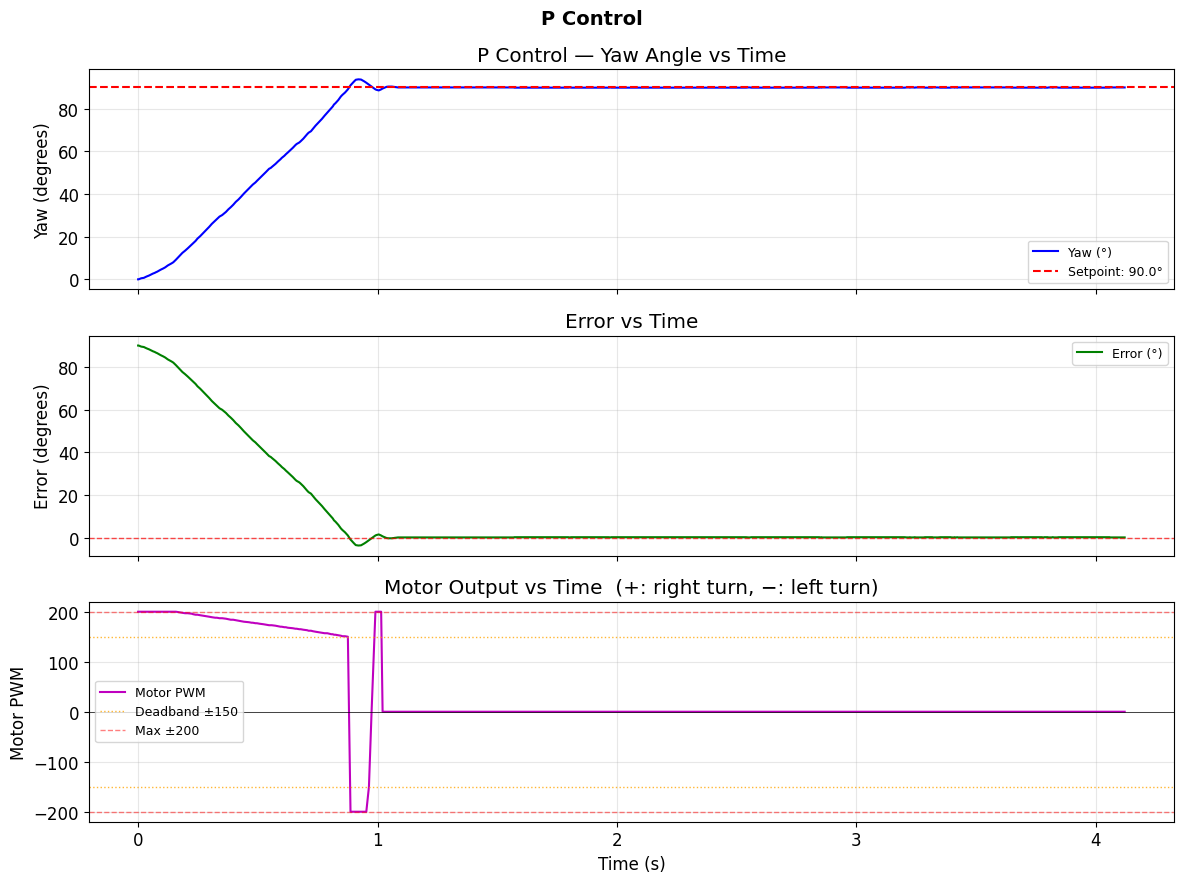

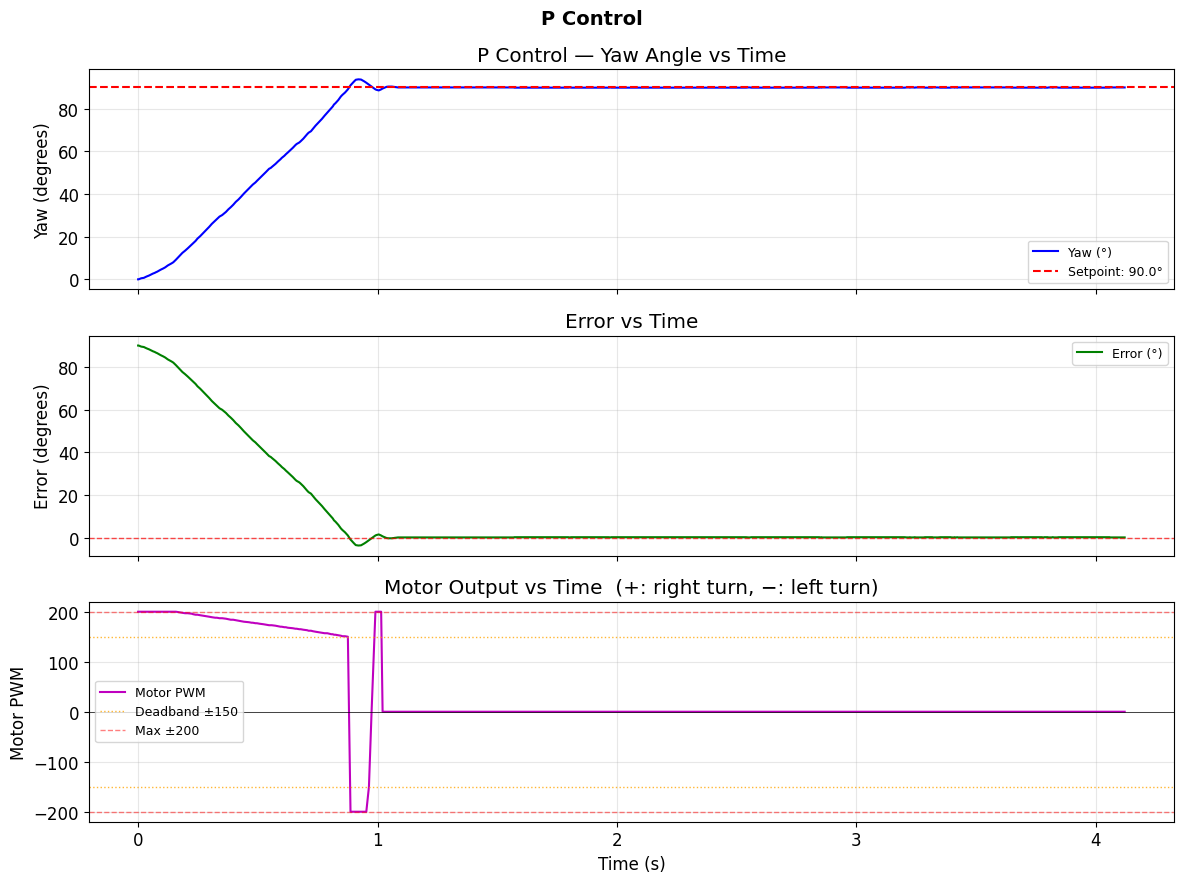

In [31]:
plot_orient_results(df_p, title='P Control', target_deg=TARGET_P)

---
## 5. Experiment 2 — PD Control

Adding derivative damps the motor signal when the error is changing fast  
(robot spinning quickly), reducing overshoot.

Target = **-180°** to test:
1. Whether KP is large enough to build full speed at 180° error
2. Whether the angle wrap-around code works correctly (yaw can jump ±180)

**Starting KD:** ~KP/100 ≈ 0.009 (small — derivative of angle ≈ angular velocity)

In [32]:
OKP = 2.5
OKD = 0.05  # was 0.4 — that was too large: at 300 deg/s D term = 120 PWM which overpowers P at 48° error
OKI = 0.0
TARGET_PD = -180.0  # degrees — tests wrap-around

set_orient_gains(kp=OKP, ki=OKI, kd=OKD)
set_orient_target(TARGET_PD)

Orientation gains set -> ORIENT_GAINS|2.500|0.000|0.050
Target set request -180.0 deg -> ORIENT_TARGET|-180.000


'ORIENT_TARGET|-180.000'

In [33]:
input("Place robot on flat surface facing 0 deg, then press Enter ...")
df_pd = run_orient_experiment(run_duration_s=8.0, label="PD")
debug_orient_df(df_pd, "PD", target_deg=TARGET_PD)


  [PD] Sending ORIENT_START ...
  [PD] Retrieving data ...
  [PD] Got 982 samples
  [PD] Raw head: ['OPID|0|1800|200|115778', 'OPID|0|-1800|-200|115786', 'OPID|0|-1800|-200|115791']
  [PD] Raw tail: ['OPID|1799|1|0|120485', 'OPID|1799|1|0|120488', 'OPID|1799|1|0|120495']
  [PD] Avg PID loop interval: 4.8 ms  (208 Hz)

===== DEBUG: PD =====
First 5 samples:
   time_s  yaw_deg  error_deg  motor_pwm
0   0.000      0.0      180.0        200
1   0.008      0.0     -180.0       -200
2   0.013      0.0     -180.0       -200
3   0.020      0.0     -180.0       -200
4   0.031     -0.4     -179.6       -200
Last 5 samples:
     time_s  yaw_deg  error_deg  motor_pwm
977   4.697    179.9        0.1          0
978   4.700    179.9        0.1          0
979   4.707    179.9        0.1          0
980   4.710    179.9        0.1          0
981   4.717    179.9        0.1          0
Yaw range: -180.0 to +180.0 deg
Error range: -180.0 to +180.0 deg
Motor PWM counts: +=29  -=117  0=836
Final error: +0.1 

Saved → lab6_pd_control.png


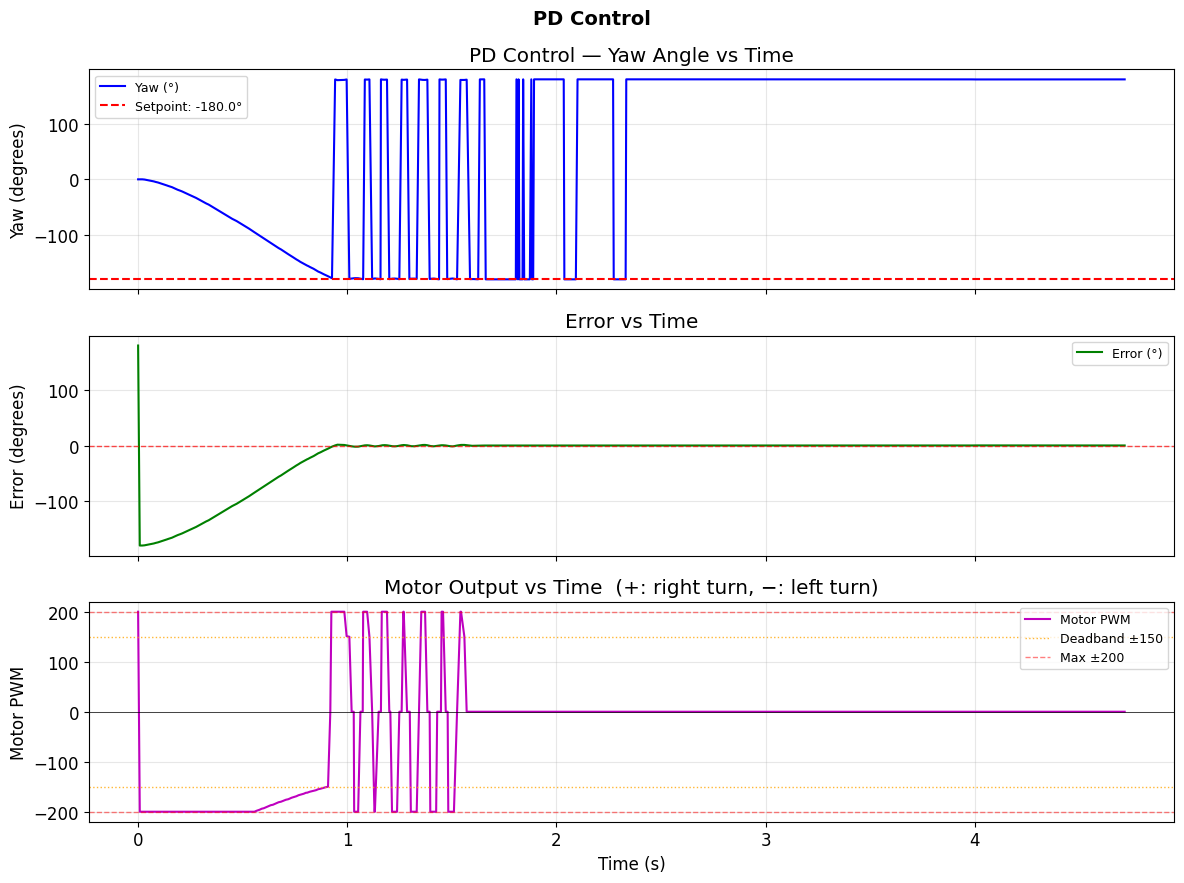

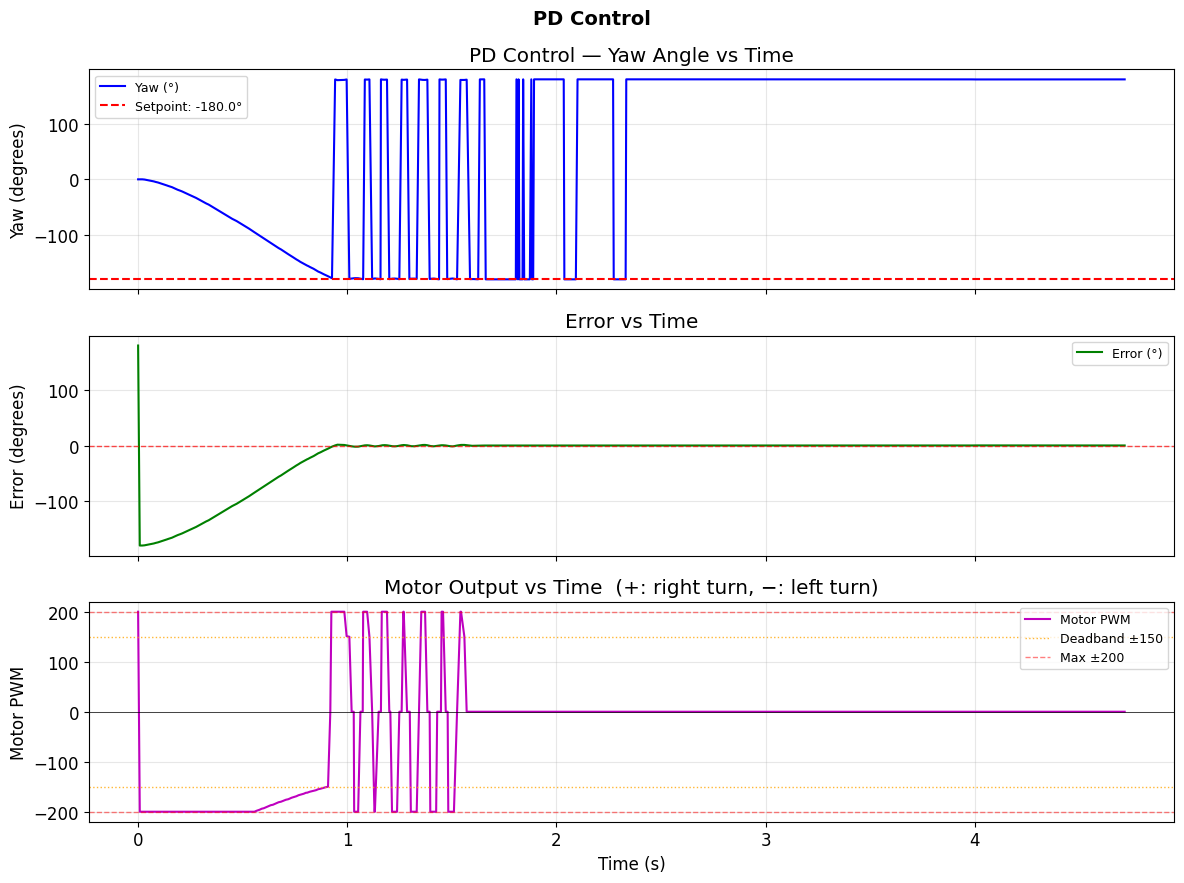

In [34]:
plot_orient_results(df_pd, title='PD Control', target_deg=TARGET_PD)

Orientation gains set -> ORIENT_GAINS|2.500|0.000|0.050
Target set request 90.0 deg -> ORIENT_TARGET|90.000
  [PD@90] Sending ORIENT_START ...
  [PD@90] Retrieving data ...
  [PD@90] Got 991 samples
  [PD@90] Raw head: ['OPID|0|900|200|185480', 'OPID|0|900|200|185484', 'OPID|0|900|200|185495']
  [PD@90] Raw tail: ['OPID|894|6|0|189859', 'OPID|894|6|0|189861', 'OPID|894|6|0|189864']
  [PD@90] Avg PID loop interval: 4.4 ms  (226 Hz)
Orientation gains set -> ORIENT_GAINS|2.500|0.000|0.000


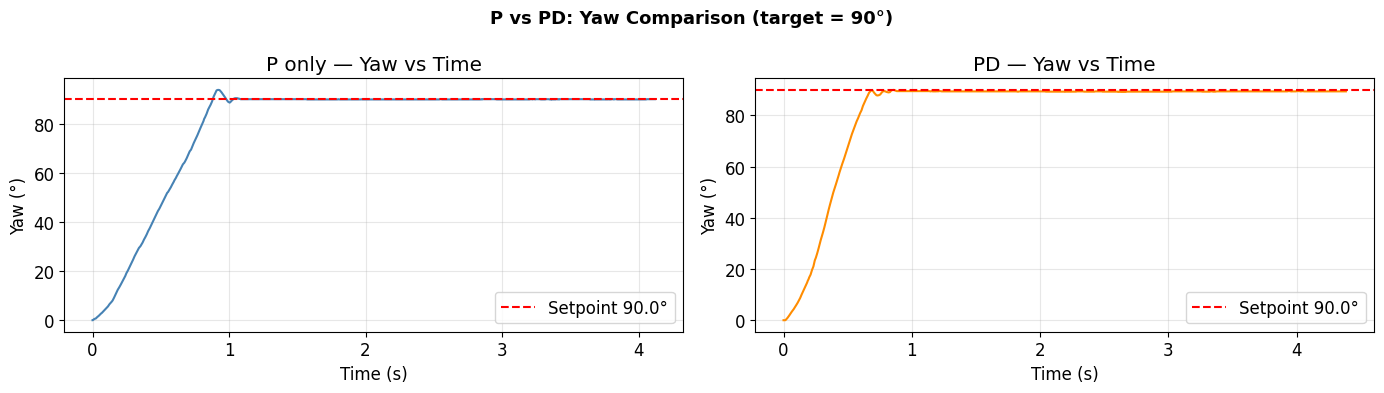

In [35]:
# ── P vs PD overshoot comparison ──────────────────────────────────────────────
# Use same target (90°) so the comparison is fair
set_orient_gains(kp=OKP, ki=0.0, kd=OKD)
set_orient_target(TARGET_P)   # back to 90°

input("[PD at 90°] Place robot facing 0°, press Enter ...")
df_pd_90 = run_orient_experiment(run_duration_s=8.0, label="PD@90")

# Reset for comparison
set_orient_gains(kp=OKP, ki=0.0, kd=0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (df_x, lbl, color) in zip(axes, [
    (df_p,     'P only',  'steelblue'),
    (df_pd_90, 'PD',       'darkorange'),
]):
    ax.plot(df_x['time_s'], df_x['yaw_deg'], color=color, lw=1.5)
    ax.axhline(TARGET_P, color='r', linestyle='--', lw=1.5, label=f'Setpoint {TARGET_P}°')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Yaw (°)')
    ax.set_title(f'{lbl} — Yaw vs Time')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('P vs PD: Yaw Comparison (target = 90°)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lab6_p_vs_pd.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Derivative Kick Demo + Lowpass Filter Fix

When the setpoint changes mid-run, the error jumps suddenly.  
This causes a large spike in the derivative term → motor runs to max speed.

**Fix:** apply a low-pass filter on the derivative term in Arduino:
```cpp
orient_dF = alpha * d_raw + (1 - alpha) * orient_dF;
```
A low alpha (e.g., 0.002) heavily weights past values, blocking the high-frequency spike.

**Test:** start at 90°, after 3 s change target to -90°, observe derivative spike.

In [36]:
# Without LPF: alpha = 1.0 → no filtering (raw derivative)
# This needs to be set in Arduino via a separate command or flashed directly.
# Run with KD large enough to see the kick clearly.
OKP_KICK = 2.5
OKD_KICK = 0.05   # exaggerated KD to make the spike more visible

set_orient_gains(kp=OKP_KICK, ki=0.0, kd=OKD_KICK)
set_orient_target(90.0)

print("Running derivative kick demo (no LPF — alpha=1.0 on Arduino).")
print("Will change setpoint from 90° to -90° at t=3s.")
input("Place robot facing 0°, press Enter ...")
df_kick = run_orient_experiment(
    run_duration_s=7.0, label="D-kick",
    setpoint_change=-90.0, change_at_s=3.0
)

print("\nNext run: same test but with LPF (alpha=0.002) flashed on Arduino.")

Orientation gains set -> ORIENT_GAINS|2.500|0.000|0.050
Target set request 90.0 deg -> ORIENT_TARGET|90.000
Running derivative kick demo (no LPF — alpha=1.0 on Arduino).
Will change setpoint from 90° to -90° at t=3s.
  [D-kick] Sending ORIENT_START ...
  [D-kick] Changing target to -90.0 deg at t=3.0s
Target set request -90.0 deg -> ORIENT_TARGET|-90.000
  [D-kick] Retrieving data ...
  [D-kick] Got 1060 samples
  [D-kick] Raw head: ['OPID|0|900|200|246957', 'OPID|0|900|200|246964', 'OPID|1|899|200|246974']
  [D-kick] Raw tail: ['OPID|-894|-6|0|252312', 'OPID|-894|-6|0|252315', 'OPID|-894|-6|0|252322']
  [D-kick] Avg PID loop interval: 5.1 ms  (197 Hz)

Next run: same test but with LPF (alpha=0.002) flashed on Arduino.


In [37]:
# With LPF: flash Arduino with alpha = 0.002, then re-run same test
# (same gains, same setpoint change sequence)
input("Flash Arduino with LPF alpha=0.002, then place robot facing 0°, press Enter ...")
set_orient_target(90.0)   # reset target to 90°
df_kick_lpf = run_orient_experiment(
    run_duration_s=7.0, label="D-kick+LPF",
    setpoint_change=-90.0, change_at_s=3.0
)

Target set request 90.0 deg -> ORIENT_TARGET|90.000
  [D-kick+LPF] Sending ORIENT_START ...
  [D-kick+LPF] Changing target to -90.0 deg at t=3.0s
Target set request -90.0 deg -> ORIENT_TARGET|-90.000
  [D-kick+LPF] Retrieving data ...
  [D-kick+LPF] Got 1041 samples
  [D-kick+LPF] Raw head: ['OPID|0|900|200|311487', 'OPID|0|900|200|311489', 'OPID|-2|902|200|311503']
  [D-kick+LPF] Raw tail: ['OPID|-900|0|0|317110', 'OPID|-900|0|0|317113', 'OPID|-900|0|0|317120']
  [D-kick+LPF] Avg PID loop interval: 5.4 ms  (185 Hz)


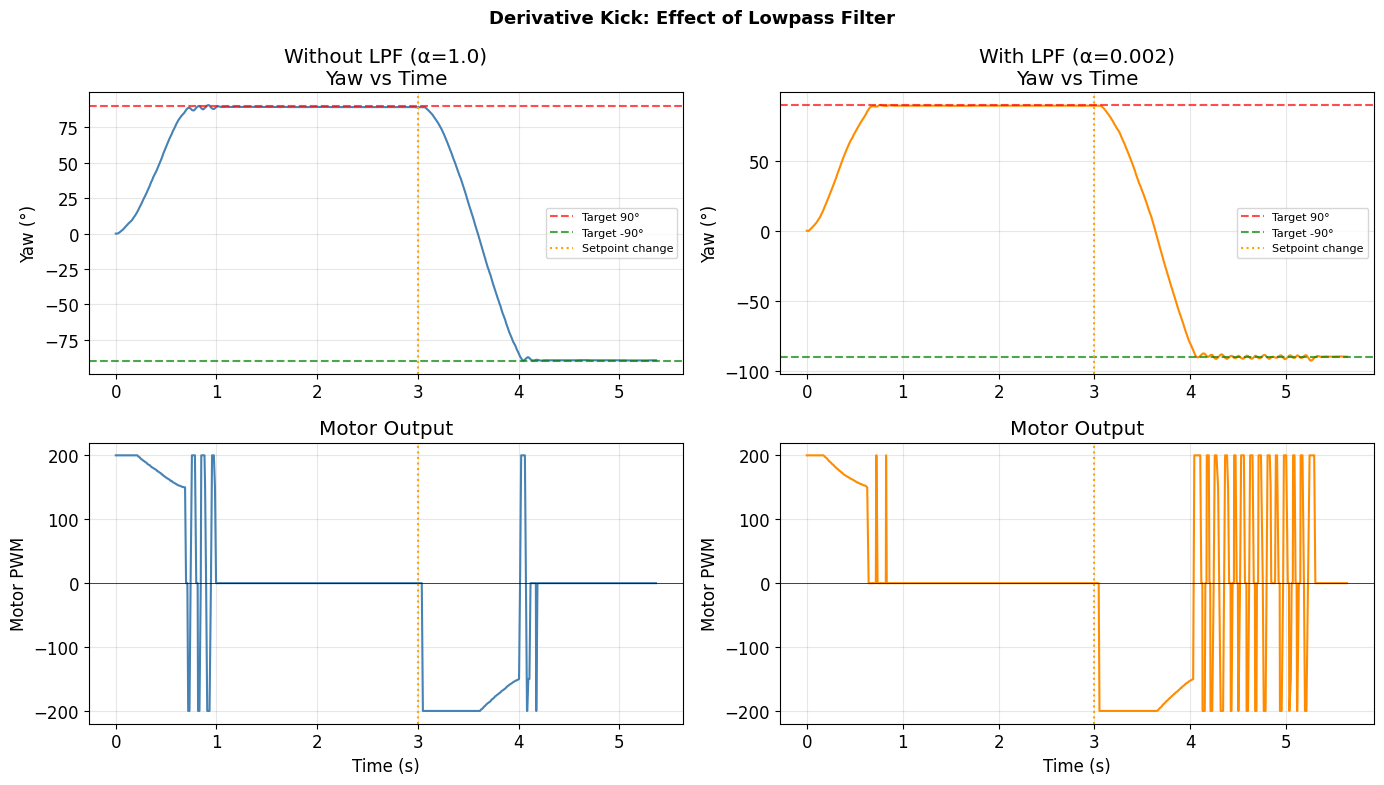

In [38]:
# ── Derivative kick comparison plot ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (df_x, lbl) in enumerate([
    (df_kick,     'Without LPF (α=1.0)'),
    (df_kick_lpf, 'With LPF (α=0.002)'),
]):
    color = 'steelblue' if col == 0 else 'darkorange'

    # Yaw row
    axes[0, col].plot(df_x['time_s'], df_x['yaw_deg'], color=color, lw=1.5)
    axes[0, col].axhline(90,  color='r', linestyle='--', lw=1.5, alpha=0.7, label='Target 90°')
    axes[0, col].axhline(-90, color='g', linestyle='--', lw=1.5, alpha=0.7, label='Target -90°')
    axes[0, col].axvline(3.0, color='orange', linestyle=':', lw=1.5, label='Setpoint change')
    axes[0, col].set_ylabel('Yaw (°)')
    axes[0, col].set_title(f'{lbl}\nYaw vs Time')
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(alpha=0.3)

    # Motor row
    axes[1, col].plot(df_x['time_s'], df_x['motor_pwm'], color=color, lw=1.5)
    axes[1, col].axhline(0, color='k', lw=0.5)
    axes[1, col].axvline(3.0, color='orange', linestyle=':', lw=1.5)
    axes[1, col].set_ylabel('Motor PWM')
    axes[1, col].set_xlabel('Time (s)')
    axes[1, col].set_title('Motor Output')
    axes[1, col].grid(alpha=0.3)

plt.suptitle('Derivative Kick: Effect of Lowpass Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lab6_derivative_kick.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Experiment 3 — PID Control

Adding the integral term eliminates steady-state error: if the robot sits slightly  
off target (P+D not strong enough to overcome friction), the integral winds up  
until the motors actually move.

**Tuning:** Start with small KI (e.g., 0.05) — integral is a slow correction.

In [53]:
OKP = 2.5
OKD = 0.05  # was 0.4 — too large, see PD cell comment
OKI = 0.05  # small — integral is a gentle correction
TARGET_PID = 90.0

set_orient_gains(kp=OKP, ki=OKI, kd=OKD)
set_orient_target(TARGET_PID)

Orientation gains set -> ORIENT_GAINS|2.500|0.050|0.050
Target set request 90.0 deg -> ORIENT_TARGET|90.000


'ORIENT_TARGET|90.000'

In [40]:
input("Place robot on flat surface facing 0 deg, press Enter ...")
df_pid = run_orient_experiment(run_duration_s=8.0, label="PID")
debug_orient_df(df_pid, "PID", target_deg=TARGET_PID)


  [PID] Sending ORIENT_START ...
  [PID] Retrieving data ...
  [PID] Got 1015 samples
  [PID] Raw head: ['OPID|0|900|200|369812', 'OPID|0|900|200|369817', 'OPID|3|897|200|369828']
  [PID] Raw tail: ['OPID|910|-10|0|374562', 'OPID|910|-10|0|374565', 'OPID|910|-10|0|374572']
  [PID] Avg PID loop interval: 4.7 ms  (213 Hz)

===== DEBUG: PID =====
First 5 samples:
   time_s  yaw_deg  error_deg  motor_pwm
0   0.000      0.0       90.0        200
1   0.005      0.0       90.0        200
2   0.016      0.3       89.7        200
3   0.026      0.6       89.4        200
4   0.036      1.2       88.8        200
Last 5 samples:
      time_s  yaw_deg  error_deg  motor_pwm
1010   4.745     91.0       -1.0          0
1011   4.748     91.0       -1.0          0
1012   4.750     91.0       -1.0          0
1013   4.753     91.0       -1.0          0
1014   4.760     91.0       -1.0          0
Yaw range: +0.0 to +92.7 deg
Error range: -2.7 to +90.0 deg
Motor PWM counts: +=112  -=57  0=846
Final error: -

Saved → lab6_pid_control.png


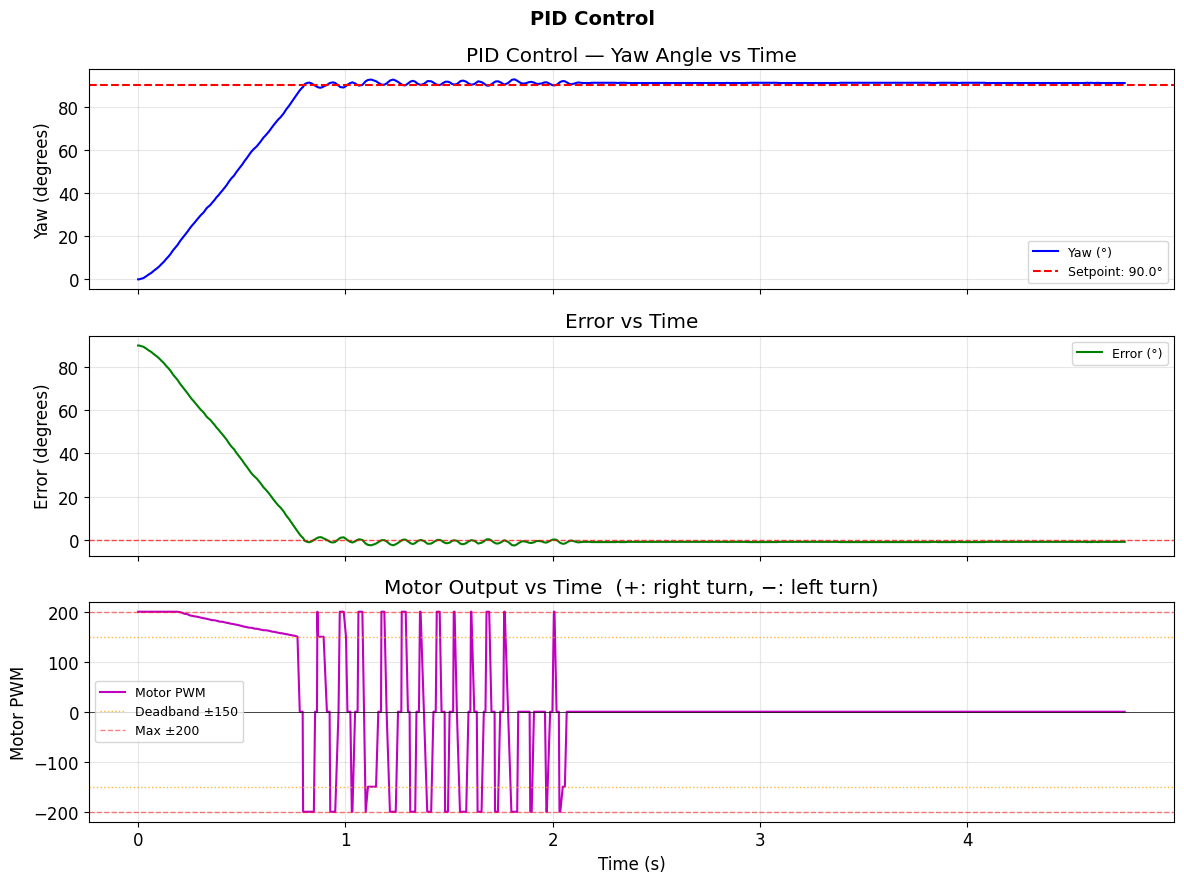

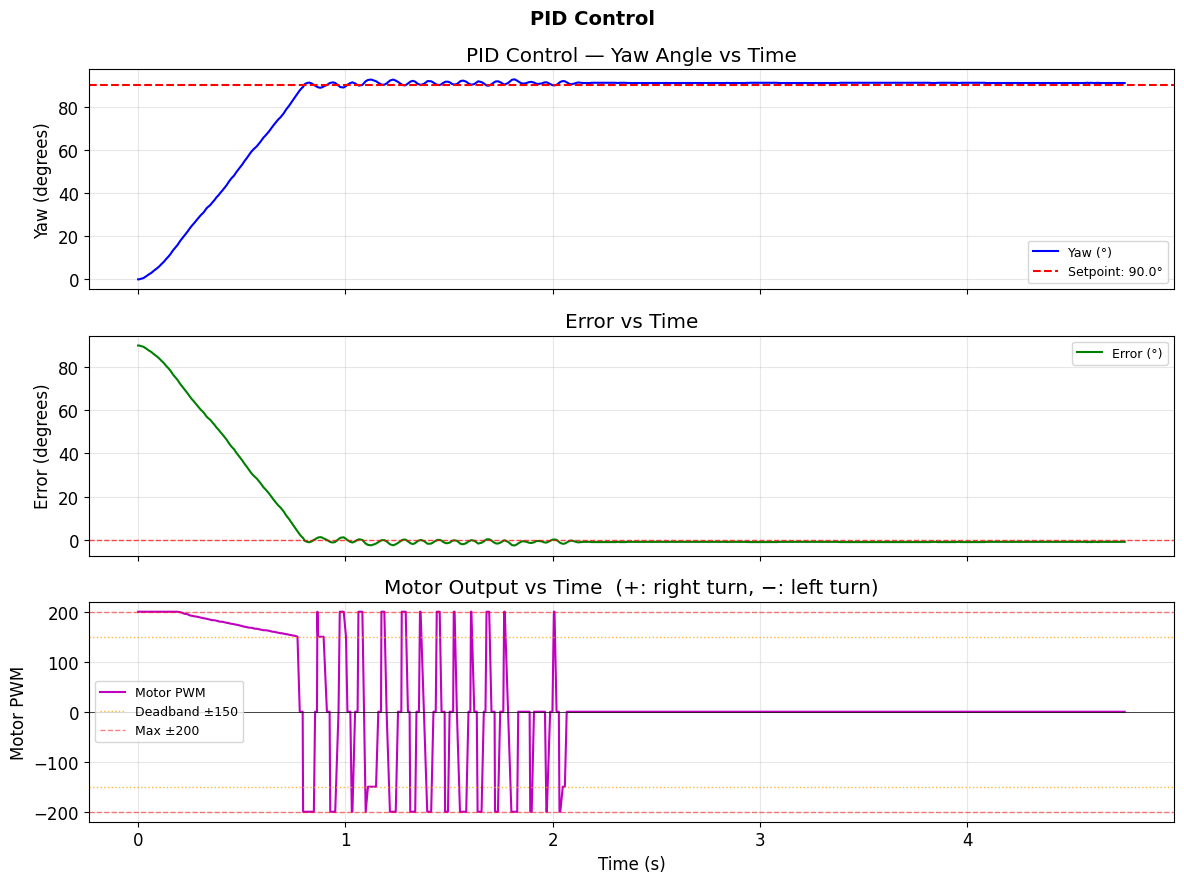

In [41]:
plot_orient_results(df_pid, title='PID Control', target_deg=TARGET_PID)

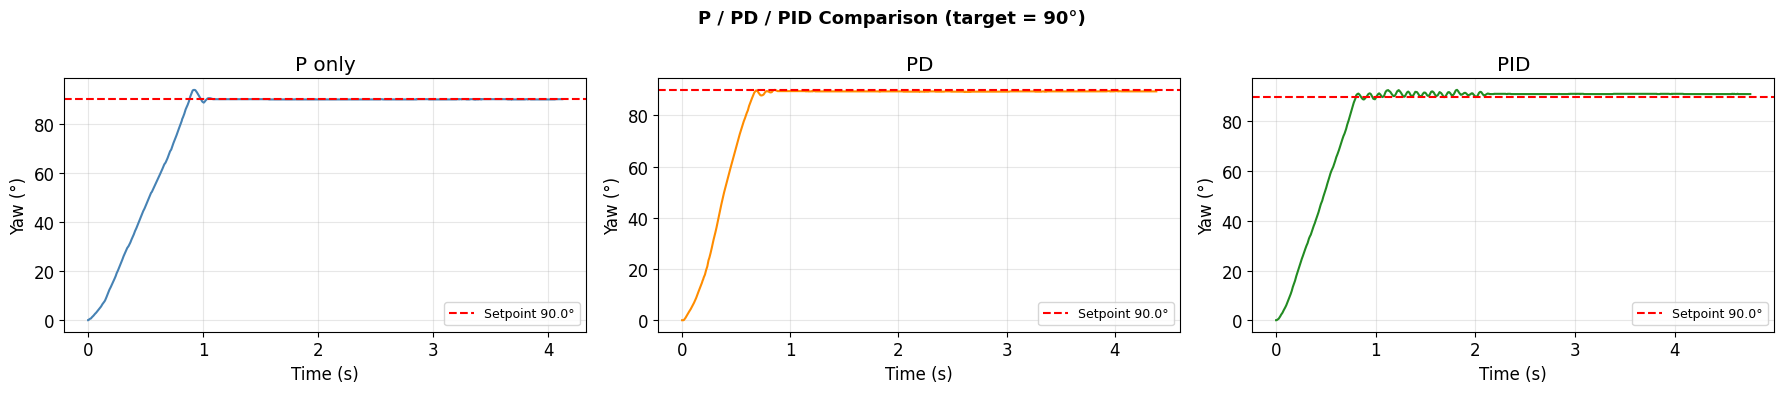

In [42]:
# ── P / PD / PID comparison (all at 90°) ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
datasets = [
    (df_p,   'P only',   'steelblue'),
    (df_pd_90, 'PD',     'darkorange'),
    (df_pid, 'PID',      'forestgreen'),
]
for ax, (df_x, lbl, color) in zip(axes, datasets):
    ax.plot(df_x['time_s'], df_x['yaw_deg'], color=color, lw=1.5)
    ax.axhline(TARGET_P, color='r', linestyle='--', lw=1.5, label=f'Setpoint {TARGET_P}°')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Yaw (°)')
    ax.set_title(f'{lbl}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('P / PD / PID Comparison (target = 90°)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lab6_pid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Experiment 4 — Setpoint Change Mid-Run

Demonstrate that the robot can switch targets in real time.  
Start at **90°**, change to **-90°** after 4 s via BLE while the robot is still running.

The robot should:
1. Converge on 90° in the first 4 s
2. Immediately react to the new -90° target and spin to it
3. Oscillate around -90° for the remainder

In [43]:
# Use the same PID gains
set_orient_gains(kp=OKP, ki=OKI, kd=OKD)
set_orient_target(90.0)   # start at 90°

CHANGE_AT_S = 4.0         # seconds after start to switch target
TARGET_INIT = 90.0
TARGET_SWITCH = -90.0

input("Place robot on flat surface facing 0°, press Enter ...")
df_switch = run_orient_experiment(
    run_duration_s=10.0, label="Setpoint-Change",
    setpoint_change=TARGET_SWITCH, change_at_s=CHANGE_AT_S
)

print(f"\nFirst 5s final yaw: {df_switch[df_switch['time_s'] <= CHANGE_AT_S]['yaw_deg'].iloc[-1]:.1f}°")
print(f"Final yaw: {df_switch['yaw_deg'].iloc[-1]:.1f}°  (target was {TARGET_SWITCH}°)")

Orientation gains set -> ORIENT_GAINS|2.500|0.050|0.050
Target set request 90.0 deg -> ORIENT_TARGET|90.000
  [Setpoint-Change] Sending ORIENT_START ...
  [Setpoint-Change] Changing target to -90.0 deg at t=4.0s
Target set request -90.0 deg -> ORIENT_TARGET|-90.000
  [Setpoint-Change] Retrieving data ...
  [Setpoint-Change] Got 997 samples
  [Setpoint-Change] Raw head: ['OPID|0|900|200|425545', 'OPID|0|900|200|425553', 'OPID|0|900|200|425564']
  [Setpoint-Change] Raw tail: ['OPID|10|-910|-200|430128', 'OPID|-18|-882|-200|430139', 'OPID|-41|-859|-200|430150']
  [Setpoint-Change] Avg PID loop interval: 4.6 ms  (216 Hz)

First 5s final yaw: 89.9°
Final yaw: -4.1°  (target was -90.0°)


Saved → lab6_pid_control_with_setpoint_change.png


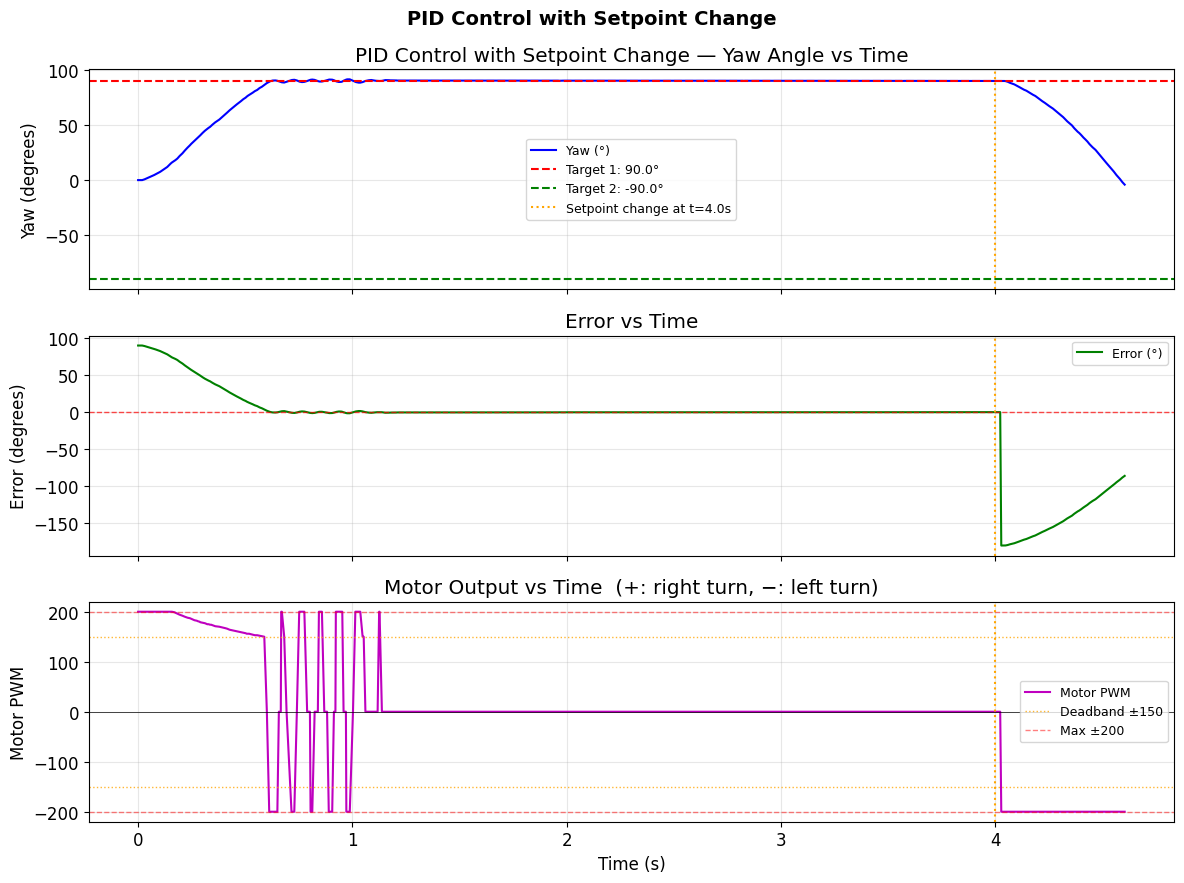

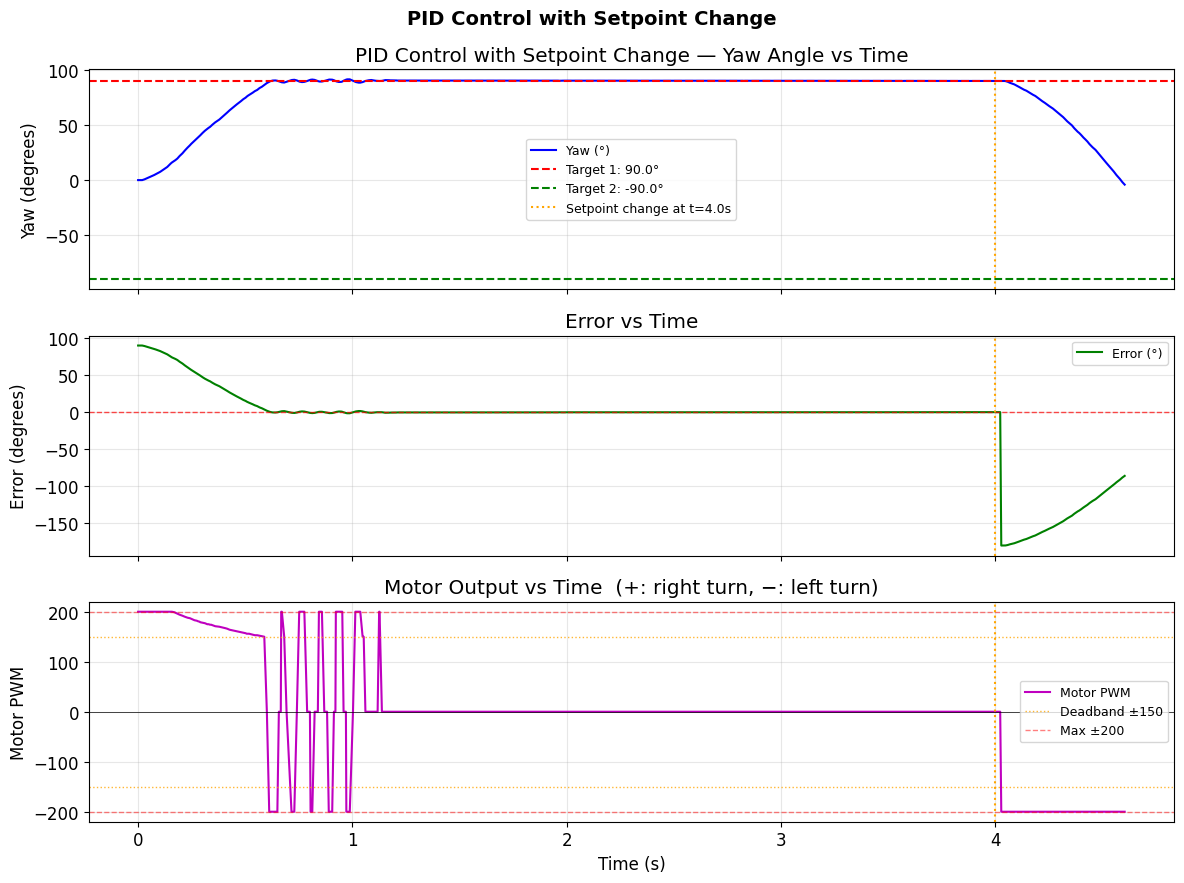

In [44]:
plot_orient_results(
    df_switch,
    title='PID Control with Setpoint Change',
    target_deg=TARGET_INIT,
    target2_deg=TARGET_SWITCH,
    change_at_s=CHANGE_AT_S
)

---
## 9. Summary

In [45]:
# ── Summary table ─────────────────────────────────────────────────────────────
results = []
for (df_x, lbl, kp_v, ki_v, kd_v, tgt) in [
    (df_p,     'P only',  2.5,  0.0,   0.0,   90.0),
    (df_pd_90, 'PD',      2.5,  0.0,   0.05,  90.0),
    (df_pid,   'PID',     2.5,  0.05,  0.05,  90.0),
]:
    if len(df_x):
        final_err  = df_x['error_deg'].iloc[-1]
        max_over   = (df_x['yaw_deg'] - tgt).abs().max()
        loop_ms    = df_x['time_ms'].diff().dropna().mean() if len(df_x) > 1 else float('nan')
        results.append({
            'Controller':     lbl,
            'KP':             kp_v,
            'KI':             ki_v,
            'KD':             kd_v,
            'Final Error (°)':f'{final_err:+.1f}',
            'Max Overshoot (°)': f'{max_over:.1f}',
            'Avg Loop (ms)':  f'{loop_ms:.1f}',
        })

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

Controller  KP   KI   KD Final Error (°) Max Overshoot (°) Avg Loop (ms)
    P only 2.5 0.00 0.00            +0.1              90.0           4.3
        PD 2.5 0.00 0.05            +0.6              90.0           4.4
       PID 2.5 0.05 0.05            -1.0              90.0           4.7


---
## 10. Disconnect

In [55]:
try:
    ble.disconnect()
    print("Disconnected from Artemis.")
except Exception as e:
    print(f"Already disconnected: {e}")

Disconnected from Artemis.
